# Scientific-role matches by rank

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
DATA_PATH = ROOT / "data" / "synthetic_perlmutter_memberships_2020_2026.csv"
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from artifact_utils import load_memberships, build_user_graph, node_scores, latest_roles, exact_top


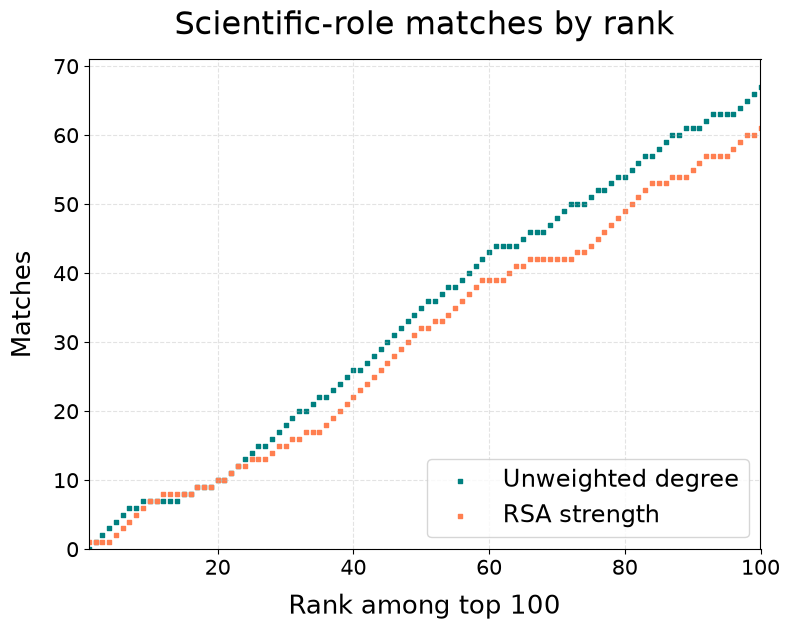

In [6]:
memberships = load_memberships(DATA_PATH).query("year == 2025")
graph, _ = build_user_graph(memberships)
scores = node_scores(graph).merge(latest_roles(memberships, graph.vs["name"]), on="user_id")
match_roles = {"FACULTY", "PROSTAFF", "SCIENTST", "POSTDOC"}

series = []
for column, label in [("degree", "Unweighted degree"), ("rsa_strength", "RSA strength")]:
    ranked = exact_top(scores, column, 100)
    ranked["rank"] = np.arange(1, 101)
    ranked["matches"] = ranked["role_code"].isin(match_roles).cumsum()
    series.append((label, ranked))

fig, ax = plt.subplots(figsize=(8.0, 6.4))
ax.scatter(series[0][1]["rank"], series[0][1]["matches"], s=10, marker="s", color="teal", label=series[0][0])
ax.scatter(series[1][1]["rank"], series[1][1]["matches"], s=10, marker="s", color="coral", label=series[1][0])
ax.set_title("Scientific-role matches by rank", fontsize=23, pad=18)
ax.set_xlabel("Rank among top 100", fontsize=19, labelpad=10)
ax.set_ylabel("Matches", fontsize=19, labelpad=12)
ax.set_xlim(1, 100)
ax.set_ylim(0, max(item[1]["matches"].max() for item in series) + 4)
ax.tick_params(axis="both", labelsize=15)
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="lower right", fontsize=17, frameon=True)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "scientific_role_matches_by_rank.png", dpi=300, bbox_inches="tight")
plt.show()
